In [44]:
import jax
from jax import grad, hessian, vmap
import jax.numpy as jnp

from scipy.spatial.distance import cdist
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import matplotlib.pyplot as plt

import numpy as np
from numpy.random import normal, uniform

import tqdm
import torch
import time

In [135]:
def reorder_mesh(points, tol=1e-12):
    """
    Reorder the mesh points so that the interior nodes come first and the boundary nodes come last.

    Also, update the triangle connectivity to reflect the new ordering.

    Returns:
       new_points: reordered points array.
       new_triangles: updated triangles connectivity.
       interior_nodes: list of new indices corresponding to interior nodes.
       boundary_nodes: list of new indices corresponding to boundary nodes.
       perm: permutation array such that new_index = perm[old_index].
    """
    n_points = points.shape[0]
    interior_nodes = []
    boundary_nodes = []
    for i, (x, y) in enumerate(points):
        if abs(x) < tol or abs(x-1) < tol or abs(y) < tol or abs(y-1) < tol:
            boundary_nodes.append(i)
        else:
            interior_nodes.append(i)
    # New ordering: interior nodes first, then boundary nodes
    new_order = interior_nodes + boundary_nodes
    new_points = points[new_order, :]

    # Create permutation: for each old index, store its new index.
    perm = np.zeros(n_points, dtype=int)
    inv_perm = np.zeros(n_points, dtype=int)
    for new_idx, old_idx in enumerate(new_order):
        perm[old_idx] = new_idx
        inv_perm[new_idx] = old_idx

    # Also, update the lists of interior and boundary nodes to reflect new ordering.
    new_interior = list(range(len(interior_nodes)))         # interior indices now are 0,1,..., len(interior)-1
    new_boundary = list(range(len(interior_nodes), n_points))  # boundary indices follow

    return new_points, new_interior, new_boundary, perm, inv_perm

def a_coefficient(x, y):
    """
    Rough coefficient a(x,y) as given:
      a(x,y) = 1/6 * [
          (1.1 + sin(10π x))/(1.1 + sin(10π y)) +
          (1.1 + sin(26π y))/(1.1 + cos(26π x)) +
          (1.1 + cos(34π x))/(1.1 + sin(34π y)) +
          (1.1 + sin(62π y))/(1.1 + cos(62π x)) +
          (1.1 + cos(130π x))/(1.1 + sin(130π y)) +
          sin(4x^2y^2) + 1
      ].
    """
    term1 = (1.1 + np.sin(10*np.pi*x))/(1.1 + np.sin(10*np.pi*y))
    term2 = (1.1 + np.sin(26*np.pi*y))/(1.1 + np.cos(26*np.pi*x))
    term3 = (1.1 + np.cos(34*np.pi*x))/(1.1 + np.sin(34*np.pi*y))
    term4 = (1.1 + np.sin(62*np.pi*y))/(1.1 + np.cos(62*np.pi*x))
    term5 = (1.1 + np.cos(130*np.pi*x))/(1.1 + np.sin(130*np.pi*y))
    term6 = np.sin(4 * x**2 * y**2)
    return (1.0/6.0) * (term1 + term2 + term3 + term4 + term5 + term6 + 1.0)

def a_dx(x, y):
    """
    Rough coefficient a(x,y) as given:
      a(x,y) = 1/6 * [
          (1.1 + sin(10π x))/(1.1 + sin(10π y)) +
          (1.1 + sin(26π y))/(1.1 + cos(26π x)) +
          (1.1 + cos(34π x))/(1.1 + sin(34π y)) +
          (1.1 + sin(62π y))/(1.1 + cos(62π x)) +
          (1.1 + cos(130π x))/(1.1 + sin(130π y)) +
          sin(4x^2y^2) + 1
      ].
    """
    term1 = 10*np.pi*np.cos(10*np.pi*x)/(1.1 + np.sin(10*np.pi*y))
    term2 = 26*np.pi*(np.sin(26*np.pi*y)+1.1)*np.sin(26*np.pi*x)/(np.cos(26*np.pi*x)+1.1)**2
    term3 = -34*np.pi*np.sin(34*np.pi*x)/(1.1 + np.sin(34*np.pi*y))
    term4 = 62*np.pi*(np.sin(62*np.pi*y)+1.1)*np.sin(62*np.pi*x)/(np.cos(62*np.pi*x)+1.1)**2
    term5 = -130*np.pi*np.sin(130*np.pi*x)/(1.1 + np.sin(130*np.pi*y))
    term6 = 8*x*y**2*np.cos(4 * x**2 * y**2)
    return (1.0/6.0) * (term1 + term2 + term3 + term4 + term5 + term6)

def a_dy(x, y):
    """
    Rough coefficient a(x,y) as given:
      a(x,y) = 1/6 * [
          (1.1 + sin(10π x))/(1.1 + sin(10π y)) +
          (1.1 + sin(26π y))/(1.1 + cos(26π x)) +
          (1.1 + cos(34π x))/(1.1 + sin(34π y)) +
          (1.1 + sin(62π y))/(1.1 + cos(62π x)) +
          (1.1 + cos(130π x))/(1.1 + sin(130π y)) +
          sin(4x^2y^2) + 1
      ].
    """
    term1 = -10*np.pi*(np.sin(10*np.pi*x)+1.1)*np.cos(10*np.pi*y)/(np.sin(10*np.pi*y)+1.1)**2
    term2 = 26*np.pi*np.cos(26*np.pi*y)/(1.1 + np.cos(26*np.pi*x))
    term3 = -34*np.pi*(np.cos(34*np.pi*x)+1.1)*np.cos(34*np.pi*y)/(np.sin(34*np.pi*y)+1.1)**2
    term4 = 62*np.pi*np.cos(62*np.pi*y)/(1.1 + np.cos(62*np.pi*x))
    term5 = -130*np.pi*(np.cos(130*np.pi*x)+1.1)*np.cos(130*np.pi*y)/(np.sin(130*np.pi*y)+1.1)**2
    term6 = 8*y*x**2*np.cos(4 * x**2 * y**2)
    return (1.0/6.0) * (term1 + term2 + term3 + term4 + term5 + term6)


def generate_mesh(n):
    """
    Generate a uniform mesh on [0,1]x[0,1] with n nodes per side.

    Returns:
        points: (n*n) x 2 array of nodal coordinates.
        h: mesh spacing.
    """
    h = 1.0 / (n - 1)
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.flatten(), Y.flatten()])
    return points, h

def generate_triangles(n):
    """
    Generate a triangulation for an n x n grid by dividing each square into two triangles.

    Returns:
        triangles: an array of shape (num_triangles, 3) of vertex indices.
    """
    triangles = []
    for j in range(n - 1):
        for i in range(n - 1):
            lower_left  = j * n + i
            lower_right = j * n + (i + 1)
            upper_left  = (j + 1) * n + i
            upper_right = (j + 1) * n + (i + 1)
            triangles.append([lower_left, lower_right, upper_left])
            triangles.append([lower_right, upper_right, upper_left])
    return np.array(triangles)

def local_stiffness_matrix(coords):
    """
    Compute the local stiffness matrix for a linear triangular element.

    Approximates ∫_T a(x,y) ∇φ_i·∇φ_j dx by evaluating a(x,y) at the barycenter.
    """
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    area = 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))
    xc = (x1+x2+x3)/3.0
    yc = (y1+y2+y3)/3.0
    a_val = a_coefficient(xc, yc)
    b = np.empty(3)
    c = np.empty(3)
    b[0] = y2 - y3; c[0] = x3 - x2
    b[1] = y3 - y1; c[1] = x1 - x3
    b[2] = y1 - y2; c[2] = x2 - x1
    grads = np.column_stack((b, c))/(2*area)
    Ke = a_val * area * (grads @ grads.T)
    return Ke

def local_load_vector_from_nodes(tri, points, f_data):
    """
    Compute the local load vector for a triangle using the nodal f-values.

    Approximation: be = (area/3) * [f_i, f_j, f_k]^T.
    """
    coords = points[tri]
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    x3, y3 = coords[2]
    area = 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))
    f_local = f_data[tri]
    be = (area/3.0)*f_local
    return be

def assemble_system(points, triangles, f_data):
    """
    Assemble the global stiffness matrix A and load vector b.

    f_data is a vector of source term values at the nodes.
    """
    n_points = points.shape[0]
    A_data, A_rows, A_cols = [], [], []
    b = np.zeros(n_points)
    for tri in triangles:
        coords = points[tri]
        Ke = local_stiffness_matrix(coords)
        be = local_load_vector_from_nodes(tri, points, f_data)
        for i_local, i_global in enumerate(tri):
            b[i_global] += be[i_local]
            for j_local, j_global in enumerate(tri):
                A_data.append(Ke[i_local, j_local])
                A_rows.append(i_global)
                A_cols.append(j_global)
    A = sp.coo_matrix((A_data, (A_rows, A_cols)), shape=(n_points, n_points))
    return A.tocsr(), b

def apply_dirichlet_bc(A, b, points, tol=1e-12):
    """
    Apply homogeneous Dirichlet boundary conditions (u = 0 on the boundary).

    Assumes points are already reordered with interior nodes first.
    """
    n_points = points.shape[0]
    boundary_nodes = []
    interior_nodes = []
    for i, (x, y) in enumerate(points):
        if abs(x) < tol or abs(x-1) < tol or abs(y) < tol or abs(y-1) < tol:
            boundary_nodes.append(i)
        else:
            interior_nodes.append(i)
    A_int = A[interior_nodes, :][:, interior_nodes]
    b_int = b[interior_nodes]
    return A_int, b_int, interior_nodes, boundary_nodes

def assemble_nonlinear(u, points, triangles):
    """
    Assemble the nonlinear vector N(u) and its Jacobian J(u) corresponding to the term u^3.

    We assume a mass-lumped approximation: For each triangle with vertices i,j,k,
    the local nonlinear contribution is approximated as:
         N_e = (area/3) * [u_i^3, u_j^3, u_k^3]^T,
    and its derivative (local Jacobian) is:
         (area/3)*3*[u_i^2, u_j^2, u_k^2]^T = area*[u_i^2, u_j^2, u_k^2]^T.

    Returns:
        N_global: vector of nonlinear contributions.
        J_N: diagonal sparse matrix representing the derivative.
    """
    n_nodes = len(u)
    N_global = np.zeros(n_nodes)
    diag_data = np.zeros(n_nodes)  # diagonal entries for the Jacobian
    # Loop over triangles and sum contributions
    for tri in triangles:
        coords = points[tri]
        # Compute area
        x1, y1 = coords[0]
        x2, y2 = coords[1]
        x3, y3 = coords[2]
        area = 0.5 * abs((x2 - x1)*(y3 - y1) - (x3 - x1)*(y2 - y1))
        # Local nonlinear contribution: (area/3)*[u_i^3, u_j^3, u_k^3]
        for local_idx, global_idx in enumerate(tri):
            N_global[global_idx] += (area/3.0) * u[global_idx]**3
            diag_data[global_idx] += area * u[global_idx]**2  # derivative contribution
    J_N = sp.diags(diag_data)
    return N_global, J_N

def solve_nonlinear_darcy_for_f(points, triangles, f_data, tol=1e-8, maxiter=50):
    """
    Solve the nonlinear Darcy flow PDE:
         -div(a grad(u)) + u^3 = f,
    with homogeneous Dirichlet BC.

    Uses Newton's method to solve A*u + N(u) = b.

    Returns:
        u: the solution vector (at all mesh nodes, in the reordered system).
    """
    # Assemble the linear stiffness matrix and the load vector from f_data.
    A, b = assemble_system(points, triangles, f_data)
    # Apply Dirichlet conditions (points are reordered with interior first)
    A_int, b_int, interior_nodes, boundary_nodes = apply_dirichlet_bc(A, b, points)

    # Solve initial linear problem as a starting guess.
    u_int = spla.spsolve(A_int, b_int)
    u = np.zeros(points.shape[0])
    u[interior_nodes] = u_int

    # Newton's method on the nonlinear residual: R(u) = A*u + N(u) - b = 0.
    # For the interior nodes only.
    u_vec = u.copy()
    for it in range(maxiter):
        # Assemble nonlinear vector and Jacobian over all nodes.
        N_global, J_N = assemble_nonlinear(u_vec, points, triangles)
        # Residual: R(u) = A*u + N(u) - b.
        R = A.dot(u_vec) + N_global - b
        # Restrict residual to interior nodes.
        R_int = R[interior_nodes]
        normR = np.linalg.norm(R_int)
        print(f"Newton iteration {it+1}: residual norm = {normR:e}")
        if normR < tol:
            break
        # Jacobian: J = A + J_N. Restrict to interior nodes.
        J = A + J_N
        J_int = J[interior_nodes, :][:, interior_nodes]
        # Solve for Newton step delta
        delta_int = spla.spsolve(J_int, -R_int)
        delta = np.zeros_like(u_vec)
        delta[interior_nodes] = delta_int
        # Update solution
        u_vec += delta

    return u_vec


def sample_gp_f(points, sigma=1.0, ell=0.2):
    """
    Generate a sample of f at the given points from a Gaussian process with a squared exponential kernel.

    Covariance: K(x,y) = sigma^2 * exp(-||x-y||^2/(2*ell^2)).
    """
    N = points.shape[0]
    diff = points[:, None, :] - points[None, :, :]
    dists_sq = np.sum(diff**2, axis=2)
    cov = sigma**2 * np.exp(-dists_sq/(2*ell**2))
    mean = np.zeros(N)
    f_sample = np.random.multivariate_normal(mean, cov)
    return f_sample


Newton iteration 1: residual norm = 1.239949e-07
Newton iteration 2: residual norm = 2.301032e-16
Newton iteration 1: residual norm = 8.295983e-09
Newton iteration 1: residual norm = 2.060515e-07
Newton iteration 2: residual norm = 2.478827e-16
Newton iteration 1: residual norm = 3.172886e-08
Newton iteration 2: residual norm = 1.338620e-16
Newton iteration 1: residual norm = 9.499891e-07
Newton iteration 2: residual norm = 2.070226e-15
Newton iteration 1: residual norm = 1.397820e-07
Newton iteration 2: residual norm = 2.439524e-16
Newton iteration 1: residual norm = 2.208775e-07
Newton iteration 2: residual norm = 2.195596e-16
Newton iteration 1: residual norm = 8.785922e-08
Newton iteration 2: residual norm = 2.046541e-16
Newton iteration 1: residual norm = 5.549507e-08
Newton iteration 2: residual norm = 1.601719e-16
Newton iteration 1: residual norm = 1.292406e-08
Newton iteration 2: residual norm = 1.060363e-16
Computed sample 10/200
Newton iteration 1: residual norm = 2.863316e-

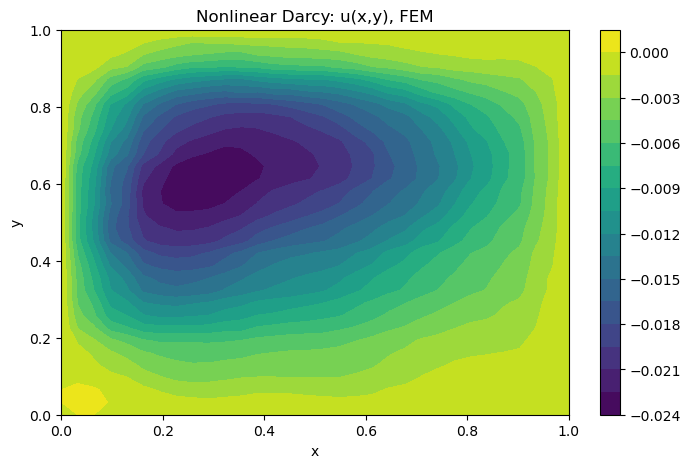

In [46]:
n = 32  # 32 nodes per side: 1024 nodes total.
points, h = generate_mesh(n)
triangles = generate_triangles(n)

# Reorder the mesh: interior nodes first, boundary nodes at the end.

num_samples = 200
N_nodes = points.shape[0]

# Arrays to store the source f, solution u, its gradients, and its Laplacian.
f_samples = np.zeros((num_samples, N_nodes))
u_samples = np.zeros((num_samples, N_nodes))

# -----------------------------------------------------------------------------
# 2.  Helper: permeability κ(x) and RHS f(x)  (element‑wise evaluation)
# -----------------------------------------------------------------------------

for i in range(num_samples):
    f_data = sample_gp_f(points, sigma=1.0, ell=0.2)
    #f_data = np.ones(N_nodes)
    f_samples[i, :] = f_data
    # Solve the nonlinear PDE: -div(a grad(u)) + u^3 = f.
    u = solve_nonlinear_darcy_for_f(points, triangles, f_data, tol=1e-8, maxiter=50)
    u_samples[i, :] = u

    if (i+1) % 10 == 0:
        print(f"Computed sample {i+1}/{num_samples}")

# Plot an example: solution u and its Laplacian for the first sample.
U = u_samples[0, :].reshape((n, n))
X = points[:, 0].reshape((n, n))
Y = points[:, 1].reshape((n, n))

plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
cp1 = plt.contourf(X, Y, U, levels=20, cmap='viridis')
plt.colorbar(cp1)
plt.title("Nonlinear Darcy: u(x,y), FEM")
plt.xlabel("x"); plt.ylabel("y")

plt.show()

In [213]:
points

array([[0.        , 0.        ],
       [0.03225806, 0.        ],
       [0.06451613, 0.        ],
       ...,
       [0.93548387, 1.        ],
       [0.96774194, 1.        ],
       [1.        , 1.        ]], shape=(1024, 2))

In [136]:
start = time.time()
u_true = solve_nonlinear_darcy_for_f(points, triangles, np.ones(N_nodes), tol=1e-8, maxiter=50)
end = time.time()

Newton iteration 1: residual norm = 6.455904e-07
Newton iteration 2: residual norm = 1.418254e-15


In [137]:
end-start

0.08445477485656738

In [138]:
def f(x1,x2):
  return 1.0

def g(x1,x2):
  return 0.0

In [139]:
grid, dom_idx,bdy_idx, perm, inv_perm = reorder_mesh(points, tol=1e-12)
X_domain_tot = grid[dom_idx,:]
X_boundary_tot = grid[bdy_idx,:]

N_boundary_tot = len(X_boundary_tot)
N_domain_tot = len(X_domain_tot)

N = N_domain_tot+N_boundary_tot

u_samples_new = u_samples[:,inv_perm][:,:N_domain_tot].T
f_samples_new = f_samples[:,inv_perm][:,:N_domain_tot].T

a_vals = a_coefficient(X_domain_tot[:,0],X_domain_tot[:,1])

a_x = a_dx(X_domain_tot[:,0],X_domain_tot[:,1])
a_y = a_dy(X_domain_tot[:,0],X_domain_tot[:,1])
bdy_g = g(X_boundary_tot[:,0], X_boundary_tot[:,1])

In [140]:
used_solutions = 100
lin_samples = f_samples_new[:,:used_solutions]-u_samples_new[:,:used_solutions]**3

In [141]:
def compute_empirical_kernels_mixed(u_samples, lin_int):
    # Full kernel matrix: shape (N, N)
    K = u_samples @ u_samples.T

    # Derivatives with respect to the first argument (interior data)
    LapK_x = lin_int @ u_samples.T  # shape (N_int, N)

    # Derivatives with respect to the second argument (using interior derivative data)
    LapK_y = u_samples @ lin_int.T  # shape (N, N_int)


    # Laplacian in both arguments
    LapK_xy = lin_int @ lin_int.T  # shape (N_int, N_int)

    K_Empirical = np.block([
    [K,         LapK_y],
    [LapK_x,    LapK_xy]])

    return K_Empirical


In [142]:
def kernel_matern(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = (1+jnp.sqrt(5)*r/sigma+5/3*r**2/sigma**2)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def kernel_matern_lap(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K_dx1_2 = -5/(3*sigma**3)*(sigma+jnp.sqrt(5)*r-5*(x1-y1)**2/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  K_dx2_2 = -5/(3*sigma**3)*(sigma+jnp.sqrt(5)*r-5*(x2-y2)**2/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  K = K_dx1_2+K_dx2_2
  return K

def kernel_matern_lap2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(35*jnp.sqrt(5)*r/sigma**2-40/sigma-25*r**2/sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def K_Matern(X,Y,sigma,reg=False,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_matern(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix


def K_Matern_Lap(X,Y,sigma,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_matern_lap(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix = jnp.reshape(val, (size,size2))

  return K_matrix

def K_Matern_Lap2(X,Y,sigma,reg=False,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_matern_lap2(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix


In [143]:
#from scipy.spatial.distance import cdist
#Maximin ordering -My own code (slower but I trust it more)
from torch import cdist

def maximin(x):
    init_indices = torch.arange(len(x))[:, None]

    # Append original indices to the point data
    x = torch.cat((x, init_indices.to(x.dtype)), dim=1)
    n = x.shape[0]

    # Create array to hold the final order
    indices = torch.zeros(n, dtype=torch.long)

    # Start with the first point arbitrarily
    indices[0] = 0
    A = x[0, :-1].unsqueeze(0)  # shape: (1, d)

    # Remove the first point from x
    mask = torch.ones(n, dtype=torch.bool)
    mask[0] = False
    x = x[mask]

    for i in range(1, n):
        dists = cdist(x[:, :-1], A)  # shape: (n-i, i)
        min_dists = torch.min(dists, dim=1).values  # (n-i,)
        maximizer = torch.argmax(min_dists)  # index in x

        indices[i] = int(x[maximizer, -1].item())  # store the original index
        A = torch.cat([A, x[maximizer, :-1].unsqueeze(0)], dim=0)

        # Remove selected row from x
        mask = torch.ones(x.size(0), dtype=torch.bool)
        mask[maximizer] = False
        x = x[mask]

    return indices

x = torch.linspace(0, 1, n)

#Permutation map

P = torch.zeros(N+N_domain_tot)

grid = torch.vstack([torch.from_numpy(X_domain_tot), torch.from_numpy(X_boundary_tot)])

P[:N] = maximin(grid)

P[N:] = torch.arange(N_domain_tot)

#Reordering points according to maximin ordering

#Lengthscale of x

def lengthscale(x):
  lengths = torch.ones(len(x[:,0]))
  lengths[0] = float('inf')

  for i in range(1,len(x[:,0])):
    lengths[i] = torch.min(cdist(x[i,:][None,:],x[:i,:]))

  return lengths

grid_reordered = grid[maximin(grid)]

In [144]:
num_samples

200

In [196]:
#Reordering of kernel matrix

Theta = torch.zeros((N+N_domain_tot,N+N_domain_tot))
P = P.int()

K_Empirical = compute_empirical_kernels_mixed(u_samples[:,inv_perm].T[:,:used_solutions],  lin_samples)
K_Empirical = torch.from_numpy(K_Empirical)

Theta[:N,:N] = K_Empirical[P[:N]][:,P[:N]]
Theta[N:N+N_domain_tot,N:N+N_domain_tot] = K_Empirical[N:N+N_domain_tot,N:N+N_domain_tot]
Theta[N:N+N_domain_tot,:N] = K_Empirical[N:,P[:N]]
Theta[:N,N:N+N_domain_tot] = Theta[N:N+N_domain_tot,:N].T

Theta = Theta/num_samples

trace1 = torch.trace(Theta[:N, :N])
trace2 = torch.trace(Theta[N:, N:])
ratio = trace2/trace1

nugget = 1*10**-7

temp= torch.concatenate((torch.ones((1,N)),ratio*torch.ones((1,N_domain_tot))), axis=1)
Theta = Theta + nugget*torch.diag(temp[0])

#Lengthscales

l = lengthscale(grid_reordered)

l_extended = torch.hstack([l,l[-1]*torch.ones(N_domain_tot)])

#Sparsity patterns

def sparsity_extended(x, rho):
    # extender: indices from P[N:] cast to int
    extender = x[P[N:]]
    x = x[maximin(x)]
    x = torch.vstack([x, extender])
    dist = cdist(x, x)
    rhol = rho * torch.broadcast_to(l_extended, (x.shape[0], x.shape[0]))
    arg = torch.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]


#Sparsity parameter rho

rho = 5
x = grid

S = sparsity_extended(x,rho)

def card(j):
  s_j = S[S[:,1]==j][:,0]
  cardinality = len(s_j)
  return s_j, cardinality

N_pts = N+N_domain_tot

U = torch.zeros((N_pts,N_pts))

for j in tqdm.tqdm(range(N_pts)):
  s_j, _ =  card(j)
  Theta_redux = torch.linalg.inv(Theta[s_j][:,s_j])
  denom = torch.sqrt(Theta_redux[-1,-1])
  U[s_j,j] = Theta_redux[:,-1]/denom


100%|██████████| 1924/1924 [00:00<00:00, 2247.06it/s]


In [197]:
Permute = torch.zeros((N+N_domain_tot,N+N_domain_tot))

combo = torch.concatenate((P[:N_domain_tot+N_boundary_tot][:,None],torch.arange(N_domain_tot+N_boundary_tot)[:,None]),axis=1)

Permute[combo[:,1],combo[:,0]] = 1

Permute[N_domain_tot+N_boundary_tot:,N_domain_tot+N_boundary_tot:] = torch.eye(N_domain_tot)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

L_ROM_dense = U.T@Permute

indices = torch.nonzero(L_ROM_dense, as_tuple=False).t()
values = L_ROM_dense[indices[0], indices[1]]
L_ROM = torch.sparse_coo_tensor(indices, values, L_ROM_dense.size(), device=device)
L_ROM = L_ROM.coalesce()

In [198]:
L_UT = L_ROM_dense.shape[0]*(L_ROM_dense.shape[0]+1)/2
print(f"The proportion of nonzero entries in the lower triangular part is {torch.count_nonzero(L_ROM_dense)/L_UT}")

The proportion of nonzero entries in the lower triangular part is 0.062200501561164856


In [199]:
L_UT = L_ROM_dense[:N,:N].shape[0]*(L_ROM_dense[:N,:N].shape[0]+1)/2
print(f"The proportion of nonzero entries in the lower triangular part is {torch.count_nonzero(L_ROM_dense[:N,:N])/L_UT}")

The proportion of nonzero entries in the lower triangular part is 0.06376905739307404


In [200]:
np.sqrt(13764/2+15)

np.float64(83.04817878797824)

In [201]:
torch.count_nonzero(L_ROM_dense[:N,:N])

tensor(33466)

In [202]:
torch.count_nonzero(torch.diag(L_ROM_dense[:N,:N]))

tensor(31)

In [203]:
np.sqrt(115557/2+86)

np.float64(240.55041051721363)

In [204]:
26, 53, 83, 107, 129, 157, 178, 200, 222, 241

(26, 53, 83, 107, 129, 157, 178, 200, 222, 241)

In [205]:
# loss function
def J_ROM(z,rhs_f,bdy_g,L):
    ww = torch.cat((z,bdy_g, rhs_f-z**3),dim=0)

    ss = torch.sparse.mm(L.float(), ww.float().unsqueeze(1))
    ss = ss.squeeze(1)
    return torch.dot(ss, ss)

#grad_J=torch.autograd.grad(J)


def grad_J_ROM(v, rhs_f, bdy_g, L):
    v = v.clone().detach().requires_grad_(True)
    L = L.float()
    loss = J_ROM(v, rhs_f, bdy_g, L)
    grad_v, = torch.autograd.grad(loss, v, create_graph=False)
    return grad_v


def Hessian_ROM(v, L):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    L = L.float()
    total_rows = N + N_domain_tot  # should equal N_total = 2999.
    mtx = torch.zeros((total_rows, N_domain_tot), dtype=v.dtype, device=v.device)

    I = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)

    mtx[:N_domain_tot, :] = I
    mtx[N:N+N_domain_tot, :] = -3*torch.diag(v**2)
    
    S = torch.sparse.mm(L, mtx.float())
    return 2 * (S.t() @ S)

In [206]:
def pde_solver_ROM(X_boundary, max_iter, step_size, initial_sol, rhs_f, L):
    bdy_g = torch.zeros(N_boundary_tot).float()

    sol = initial_sol
    J_hist = [] # history of loss function values
    #J_now = J_ROM(sol,rhs_f,bdy_g,L)
    #J_hist.append(J_now)

    #print('iter = 0', 'J =', J_now) # print out history

    for iter_step in range(1, max_iter+1):
        H = Hessian_ROM(sol, L)
        grad_val = grad_J_ROM(sol, rhs_f, bdy_g, L)
        temp = torch.linalg.solve(H,grad_val.float())
        sol = sol - step_size*temp

        #J_now = J_ROM(sol,rhs_f,bdy_g,L)
        # print out history
        #J_hist.append(J_now)
        #print('iter = ', iter_step, 'Gauss-Newton step size =', step_size, ' J = ', J_now)
    return sol

In [ ]:
max_iter = 2
initial_sol = torch.from_numpy(normal(0.0, 1.0, N_domain_tot)) # random initial guess
step_size = 1
start = time.time()
sol_ROM = pde_solver_ROM(X_boundary_tot, max_iter, step_size, initial_sol, rhs_f = torch.ones(N_domain_tot).float(),L = L_ROM)
end = time.time()t

In [208]:
end-start

0.05898308753967285

Text(0, 0.5, 'y')

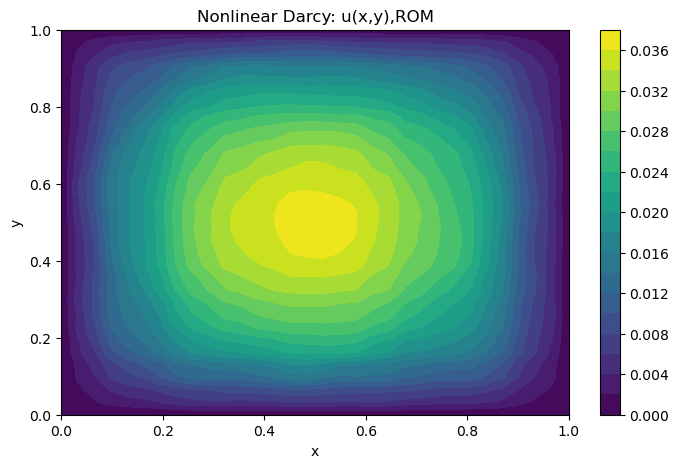

In [209]:
sol_grid = torch.zeros(n,n)

sol_grid[1:-1,1:-1] = sol_ROM[:N_domain_tot].reshape((n-2, n-2))
x = torch.linspace(0,1,n)
X, Y = torch.meshgrid(x,x)



plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
cp1 = plt.contourf(X, Y, sol_grid, levels=20, cmap='viridis')
plt.colorbar(cp1)
plt.title("Nonlinear Darcy: u(x,y),ROM")
plt.xlabel("x"); plt.ylabel("y")

Text(0, 0.5, 'y')

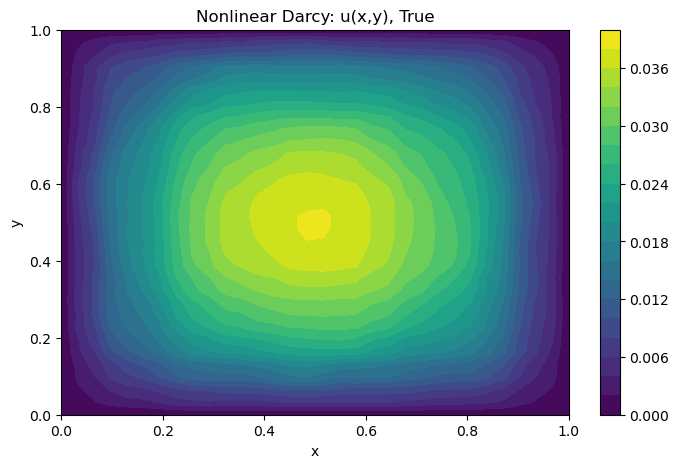

In [210]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
x = torch.linspace(0,1,n)
X, Y = torch.meshgrid(x,x)
cp1 = plt.contourf(X, Y, u_true.reshape((n,n)), levels=20, cmap='viridis')
plt.colorbar(cp1)
plt.title("Nonlinear Darcy: u(x,y), True")
plt.xlabel("x"); plt.ylabel("y")

In [211]:
sol_truth = torch.from_numpy(u_true[inv_perm][:N_domain_tot])

In [212]:
L2_err_pts = torch.linalg.norm(sol_ROM[:N_domain_tot]-sol_truth)/torch.linalg.norm(sol_truth)
L1_err_pts = torch.linalg.norm(sol_ROM[:N_domain_tot]-sol_truth,ord=1)/torch.linalg.norm(sol_truth,ord=1)
max_err_pts = torch.max(torch.abs(sol_ROM[:N_domain_tot]-sol_truth))

print('At collocation points, L1 err= ', L1_err_pts,' L2 err= ', L2_err_pts, ' max err=', max_err_pts)

At collocation points, L1 err=  tensor(0.0334, dtype=torch.float64)  L2 err=  tensor(0.0356, dtype=torch.float64)  max err= tensor(0.0018, dtype=torch.float64)


In [43]:
0.4613,0.0757, 0.0081, 0.0003, 0.0014, 0.0009, 0.0002, 0.0002, 0.0003, 0.0002

0.2406, 0.0302, 0.0109, 0.0068, 0.0048, 0.0034, 0.0029, 0.0027, 0.0022, 0.0019

(0.2406,
 0.0302,
 0.0109,
 0.0068,
 0.0048,
 0.0034,
 0.0029,
 0.0027,
 0.0022,
 0.0019)

In [203]:
0.0003, 0.0003

(0.0003, 0.0003)

Text(0, 0.5, 'Relative Error')

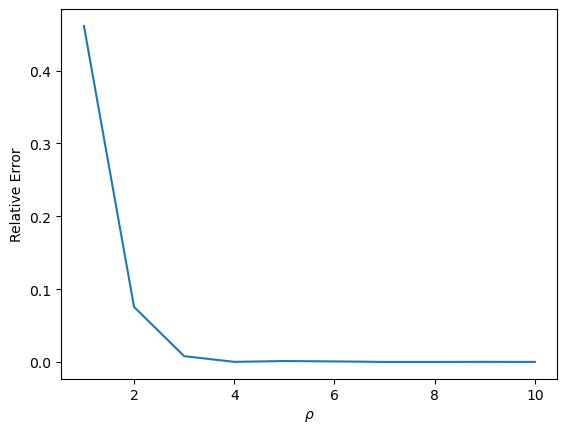

In [469]:
rho_list = [0.4613,0.0757, 0.0081, 0.0003, 0.0014, 0.0009, 0.0002, 0.0002, 0.0003, 0.0002]
plt.plot(np.arange(1,11),rho_list)
plt.xlabel(r'$\rho$')
plt.ylabel('Relative Error')

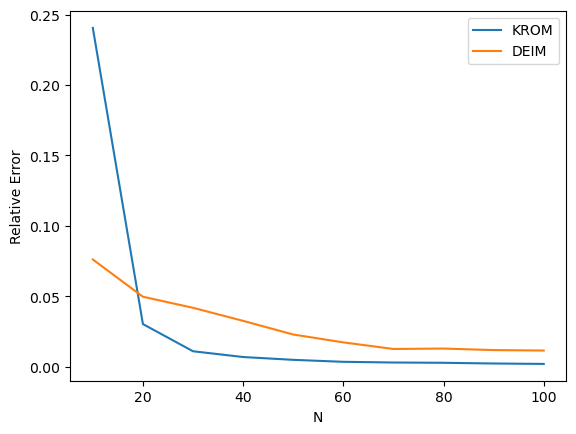

In [240]:
N_list = [0.2406, 0.0302, 0.0109, 0.0068, 0.0048, 0.0034, 0.0029, 0.0027, 0.0022, 0.0019]
N_list_DEIM = [0.07609295628867331, 0.049632088997882046,0.04176988754014835, 0.03248766758562266, 0.02279397638298986, 0.01720530081401098,0.012518325680298533,0.012815865495813905,0.011727752110828132,0.011407868448799716]
plt.plot(10*np.arange(1,11),N_list)
plt.plot(10*np.arange(1,11),N_list_DEIM)
plt.xlabel(r'N')
plt.ylabel('Relative Error')
plt.legend(['KROM','DEIM'])

Text(0, 0.5, 'y')

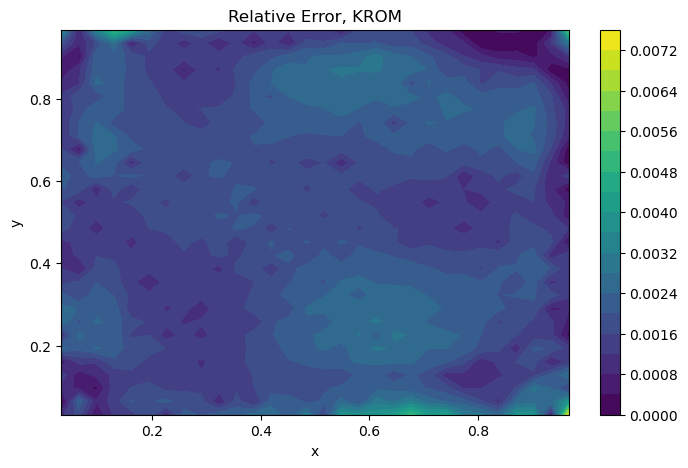

In [609]:
U_err = (torch.abs(sol_ROM[:N_domain_tot]-sol_truth)/torch.abs(sol_truth)).reshape((n-2, n-2))
X = X_domain_tot[:, 0].reshape((n-2, n-2))
Y = X_domain_tot[:, 1].reshape((n-2, n-2))

plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
cp1 = plt.contourf(X, Y, U_err, levels=20, cmap='viridis')
plt.colorbar(cp1)
plt.title("Relative Error, KROM")
plt.xlabel("x"); plt.ylabel("y")

In [438]:
err_rho[4,4] = L2_err_pts

In [439]:
err_rho

array([[0.39225164, 0.06293038, 0.00747977, 0.01263874, 0.01132218],
       [0.38719329, 0.03770098, 0.00759292, 0.01057332, 0.00725218],
       [0.37874874, 0.02546639, 0.00888844, 0.00487415, 0.00287003],
       [0.37317136, 0.02346803, 0.00797378, 0.00527474, 0.00346629],
       [0.36540222, 0.02182381, 0.00714199, 0.00461782, 0.00289843]])

In [440]:
#err_rho = np.zeros((5,5))

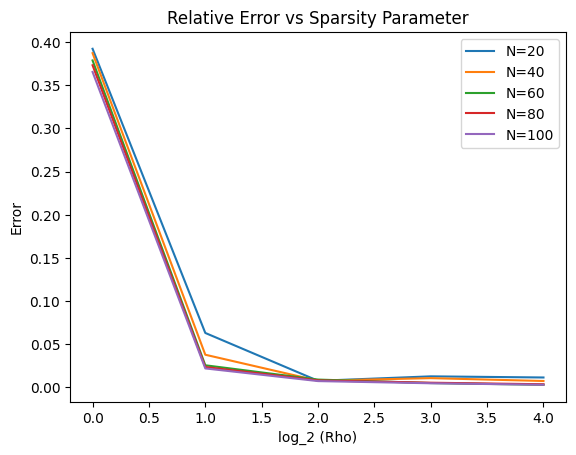

In [441]:
import numpy as np
import matplotlib.pyplot as plt

# Example: a 5x5 array of data.
# Replace 'data' with your actual 5x5 array.

# Define labels for each row
labels = ["N=20", "N=40", "N=60", "N=80", "N=100"]

# Plot each row in the same graph
for i in range(5):
    plt.plot(np.arange(5),err_rho[i, :], label=labels[i])

# Add legend, axis labels, and show
plt.xlabel("log_2 (Rho)")
plt.ylabel("Error")
plt.legend()
plt.title("Relative Error vs Sparsity Parameter")
plt.show()

In [217]:
l2_err

np.float64(2.445844177612121e-10)

In [228]:
rel_l2

np.float64(3.1801257143007757)

In [236]:
rel_l2

np.float64(3.1801257143007757)

In [ ]:
import runpy, numpy as np, numpy.linalg as npla

# Load functions
ns = runpy.run_path('/mnt/data/darcy_rom_deim.py')
build_grid = ns['build_grid']
k_func = ns['k_func']
assemble_A_varK = ns['assemble_A_varK']
gaussian_rhs_samples = ns['gaussian_rhs_samples']
newton_full_order = ns['newton_full_order']
pod_basis = ns['pod_basis']

# Reuse reduced_newton but with an injection to allow custom nonlinear map
def reduced_newton_custom(Ar, nonlinear_map, jacobian_map, b, a0=None, tol=1e-12, maxit=50):
    r = Ar.shape[0]
    a = np.zeros(r) if a0 is None else a0.copy()
    fnorm0 = None
    for it in range(maxit):
        g = nonlinear_map(a)
        F = Ar @ a + g - b
        fnorm = npla.norm(F)
        if fnorm0 is None:
            fnorm0 = max(fnorm, 1.0)
        if fnorm <= tol*fnorm0:
            break
        J = Ar + jacobian_map(a)
        delta = npla.solve(J, -F)
        alpha = 1.0
        for _ in range(8):
            at = a + alpha*delta
            Ft = Ar @ at + nonlinear_map(at) - b
            if npla.norm(Ft) < (1 - 1e-4*alpha) * fnorm:
                a = at
                break
            alpha *= 0.5
        else:
            a = a + delta
    return a

# Parameters
N = 32
N_snap = 40
r_pod = 40
m_deim = 2  # pick a small value for clear DEIM approximation

# Grid/operator
x, y, X, Y, h = build_grid(N)
K = k_func(X, Y)
A = assemble_A_varK(N, K, h)
n_int = A.shape[0]

# Interior coords
pts = np.zeros((n_int, 2))
idx=0
for j in range(1, N-1):
    for i in range(1, N-1):
        pts[idx] = [X[i,j], Y[i,j]]
        idx+=1

# Snapshots
Fsnap = gaussian_rhs_samples(pts, n_samples=N_snap, lengthscale=0.20, seed=123)
Psnap = np.zeros((n_int, N_snap))
for s in range(N_snap):
    Psnap[:, s] = newton_full_order(A, Fsnap[:, s], tol=1e-10, maxit=50, verbose=False)

Phi = pod_basis(Psnap, r=r_pod)

# Nonlinear bases
Gsnap = Psnap**3
U_full = pod_basis(Gsnap, r=r_pod)
U_nonlin = U_full[:, :m_deim]

# Classic DEIM selection
def deim(U, m):
    n,q = U.shape
    P=[]
    p1 = np.argmax(np.abs(U[:,0])); P.append(p1)
    Usel = U[:,[0]]
    for i in range(1,m):
        U_P = Usel[P,:]
        rhs = U[:,i][P]
        c = npla.solve(U_P, rhs)
        r = U[:,i] - Usel@c
        P.append(np.argmax(np.abs(r)))
        Usel = np.column_stack([Usel, U[:,i]])
    return np.array(P, dtype=int)
P_idx = deim(U_nonlin, m_deim)

# Precompute ROM operators
Ar = Phi.T @ (A @ Phi)
PTU = U_nonlin[P_idx,:]
C = npla.inv(PTU)
B = Phi.T @ (U_nonlin @ C)
R = Phi[P_idx,:]

# Exact reduced nonlinearity maps
def g_exact(a):
    pa = Phi @ a
    return Phi.T @ (pa**3)

def J_exact(a):
    pa = Phi @ a
    return Phi.T @ (3*(pa**2)[:,None]*Phi)

# DEIM reduced maps
def g_deim(a):
    Ra = R @ a
    return B @ (Ra**3)

def J_deim(a):
    Ra = R @ a
    D = 3*(Ra**2)
    return B @ (D[:,None]*R)

# Solve ROMs
f_new = np.ones(n_int)
b = Phi.T @ f_new
a_exact = reduced_newton_custom(Ar, g_exact, J_exact, b, tol=1e-12)
a_deim  = reduced_newton_custom(Ar, g_deim,  J_deim,  b, tol=1e-12)

p_fom = newton_full_order(A, f_new, tol=1e-12, maxit=60, verbose=False)
p_rom_exact = Phi @ a_exact
p_rom_deim  = Phi @ a_deim

rel_exact = npla.norm(p_rom_exact - p_fom)/npla.norm(p_fom)
rel_deim  = npla.norm(p_rom_deim  - p_fom)/npla.norm(p_fom)
deim_vs_exact = npla.norm(p_rom_exact - p_rom_deim)/npla.norm(p_rom_exact)
